# Cuaderno de prueba para descarga de imágenes de GEE

## 1. Preparación del entorno
En esta sección se instalan las librerías necesarias para trabajar con Google Earth Engine, descargar imágenes, leer rásteres georreferenciados y visualizar resultados.

In [1]:
!pip install earthengine-api requests rasterio matplotlib

## 2. Autenticación e inicialización de Google Earth Engine
Aquí se inicializa la API de Google Earth Engine con el proyecto de Google Cloud asociado. Si la sesión no está autenticada, se lanza el flujo de autenticación interactiva.

In [2]:
import ee

PROJECT_ID = "golden-tide-482516-f7"

try:
    ee.Initialize(project=PROJECT_ID)
except Exception:
    ee.Authenticate(auth_mode="notebook")
    ee.Initialize(project=PROJECT_ID)

print("Earth Engine inicializado correctamente")

Earth Engine inicializado correctamente


## 3. Importación de librerías
Se importan las librerías que se utilizarán durante el resto del notebook para tratamiento de imágenes, descarga HTTP, lectura geoespacial y exportación de resultados.

In [3]:
import requests
import rasterio
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from datetime import datetime, timezone
from pathlib import Path

## 4. Selección automática de una zona agrícola dentro de la cobertura PNOA10
En esta sección se busca automáticamente un punto de campo abierto dentro de la cobertura disponible de PNOA10. Para ello, se combinan dos criterios: que la zona sea agrícola según CORINE y que esté alejada de áreas urbanas. Además, se priorizan parcelas homogéneas para obtener una imagen visualmente más limpia.

In [ ]:
# Punto base del ejemplo oficial de PNOA10
seed_lon = -1.859852
seed_lat = 38.983734

# Radio amplio para tener variedad
search_radius_m = 80000  # 80 km

# Recorte tipo paper
paper_width_m = 115.0
paper_height_m = paper_width_m * 4968 / 8192  # ~69.74 m

# UTM de esa zona
utm_crs = "EPSG:32630"

# Parámetro: cambiar esto para ir sacando distintas zonas
candidate_rank = 3   # 0 = mejor candidato, 1 = segundo, 2 = tercero, etc...

seed_point = ee.Geometry.Point([seed_lon, seed_lat])
search_area = seed_point.buffer(search_radius_m)

# Cobertura PNOA10 en el área de búsqueda
pnoa_local = ee.ImageCollection("Spain/PNOA/PNOA10").filterBounds(search_area)

n_local = pnoa_local.size().getInfo()
print("Teselas PNOA10 en el área de búsqueda:", n_local)

if n_local == 0:
    raise ValueError("No hay cobertura PNOA10 en esta zona de búsqueda.")

covered_region = pnoa_local.geometry().intersection(search_area, 1)

# CORINE 2018
corine = ee.Image("COPERNICUS/CORINE/V20/100m/2018").select("landcover")

# Campo abierto / agrícola
# 211: non-irrigated arable land
# 212: permanently irrigated land
open_field_codes = [211, 212]

open_mask = corine.eq(open_field_codes[0])
for code in open_field_codes[1:]:
    open_mask = open_mask.Or(corine.eq(code))

# Urbano para excluir bordes y entornos de carreteras/pueblos
# 111: continuous urban fabric
# 112: discontinuous urban fabric
# 121: industrial/commercial
# 122: road and rail networks
# 123: port areas
# 124: airports
urban_codes = [111, 112, 121, 122, 123, 124]

urban_mask = corine.eq(urban_codes[0])
for code in urban_codes[1:]:
    urban_mask = urban_mask.Or(corine.eq(code))

# Excluimos zonas cercanas a urbano (buffer aprox. 500 m)
urban_buffer = urban_mask.focal_max(radius=500, units="meters")

# Candidatos finales: campo abierto y no cerca de urbano
candidate_mask = open_mask.And(urban_buffer.Not()).rename("candidate")

# Cuánto campo abierto hay alrededor
# Valores cercanos a 1 => entorno muy limpio y agrícola
open_fraction = (
    open_mask.unmask(0)
    .focal_mean(radius=400, units="meters")
    .rename("open_frac")
)

# Imagen para muestrear
sample_img = open_fraction.updateMask(candidate_mask)

samples = sample_img.sample(
    region=covered_region,
    scale=100,
    numPixels=500,
    seed=99,
    geometries=True
)

n_samples = samples.size().getInfo()
print("Puntos de campo abierto candidatos:", n_samples)

if n_samples == 0:
    raise ValueError("No se encontró campo abierto limpio. Prueba subiendo search_radius_m o quitando parte del filtro urbano.")

# Añadimos distancia al punto semilla y score combinado
def add_scores(feat):
    dist = feat.geometry().distance(seed_point, 1)
    open_frac = ee.Number(feat.get("open_frac"))
    # Priorizamos homogeneidad visual; la distancia desempata
    score = open_frac.multiply(1000000).add(dist)
    return feat.set({
        "dist_m": dist,
        "score": score
    })

ranked = samples.map(add_scores).sort("score", False)

top_n = ranked.size().getInfo()
use_rank = min(candidate_rank, max(0, top_n - 1))

chosen_feature = ee.Feature(ranked.toList(top_n).get(use_rank))
chosen_point = chosen_feature.geometry()

chosen_lon, chosen_lat = chosen_point.coordinates().getInfo()
chosen_dist = chosen_feature.get("dist_m").getInfo()
chosen_open = chosen_feature.get("open_frac").getInfo()

print("Punto elegido:")
print("lon =", chosen_lon)
print("lat =", chosen_lat)
print("Distancia al punto semilla (m):", round(chosen_dist, 1))
print("Fracción de campo abierto alrededor:", round(chosen_open, 3))
print("Ranking usado:", use_rank)

Teselas PNOA10 en el área de búsqueda: 31
Puntos de campo abierto candidatos: 81
Punto elegido:
lon = -1.8735476881175472
lat = 39.03231013344065
Distancia al punto semilla (m): 5521.7
Fracción de campo abierto alrededor: 1
Ranking usado: 3


## 5. Construcción del recorte final (AOI) con proporciones del artículo
A partir del punto seleccionado, se construye un rectángulo de tamaño similar al utilizado en el artículo base. Se preserva la proporción original de las imágenes del paper para aproximar el dominio visual del modelo.

In [5]:
chosen_point_utm = chosen_point.transform(utm_crs, 1)
x, y = chosen_point_utm.coordinates().getInfo()

aoi = ee.Geometry.Rectangle(
    [
        x - paper_width_m / 2,
        y - paper_height_m / 2,
        x + paper_width_m / 2,
        y + paper_height_m / 2
    ],
    proj=utm_crs,
    geodesic=False
)

print("AOI creada")
print("Ancho (m):", paper_width_m)
print("Alto (m):", round(paper_height_m, 3))
print("Tamaño esperado a 10 cm:", round(paper_width_m / 0.1), "x", round(paper_height_m / 0.1), "px")

AOI creada
Ancho (m): 115.0
Alto (m): 69.741
Tamaño esperado a 10 cm: 1150 x 697 px


## 6. Obtención de la ortofoto PNOA10 y generación de la URL de descarga
Se consulta la colección PNOA10 sobre el AOI final, se selecciona la imagen disponible y se genera una URL temporal de descarga en formato GeoTIFF.

In [6]:
# Filtramos de nuevo sobre el AOI final
collection = ee.ImageCollection("Spain/PNOA/PNOA10").filterBounds(aoi)

n = collection.size().getInfo()
print("Imágenes candidatas en el AOI final:", n)

if n == 0:
    raise ValueError("No hay imagen PNOA10 en el AOI final. Prueba con otra semilla o mayor radio.")

latest = ee.Image(collection.sort("system:time_start", False).first())
latest_ms = latest.get("system:time_start").getInfo()
print("Timestamp de la imagen:", latest_ms)

image = (
    collection
    .filter(ee.Filter.eq("system:time_start", latest_ms))
    .mosaic()
    .select(["R", "G", "B"])
    .clip(aoi)
)

url = image.getDownloadURL({
    "region": aoi,
    "scale": 0.1,          # 10 cm/px
    "crs": utm_crs,
    "format": "GEO_TIFF",
    "filePerBand": False,
    "name": "pnoa10_rural_demo"
})

print(url)

Imágenes candidatas en el AOI final: 1
Timestamp de la imagen: 1167609600000
https://earthengine.googleapis.com/v1/projects/golden-tide-482516-f7/thumbnails/09e659399575c906689de2aa66236443-324d91f88ae28c6ebdc1bc338b9a31fd:getPixels


## 7. Descarga del GeoTIFF
Se descarga físicamente la imagen desde la URL generada por Earth Engine y se guarda en disco como archivo GeoTIFF.

In [7]:
out_tif = "pnoa10_rural_demo.tif"

r = requests.get(url, stream=True, timeout=120)
r.raise_for_status()

with open(out_tif, "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

print("Guardado:", out_tif)

Guardado: pnoa10_rural_demo.tif


## 8. Exportación de copias a TIFF, PNG y JPG
Se crea una carpeta de salida y se guardan copias del resultado sin sobrescribir archivos previos. Además del GeoTIFF original, se generan versiones PNG y JPG para facilitar la inspección visual o el uso en aplicaciones que no trabajen con formatos georreferenciados.

In [8]:
def next_available_path(path: Path) -> Path:
    """Devuelve una ruta libre; si existe, añade ' (1)', ' (2)', etc."""
    if not path.exists():
        return path

    stem = path.stem
    suffix = path.suffix
    parent = path.parent

    i = 1
    while True:
        candidate = parent / f"{stem} ({i}){suffix}"
        if not candidate.exists():
            return candidate
        i += 1

# Carpeta de salida
output_dir = Path("prueba3_output")
output_dir.mkdir(exist_ok=True)

src_tif = Path(out_tif)
if not src_tif.exists():
    raise FileNotFoundError(f"No existe el archivo TIFF: {src_tif}")

# 1) Guardar copia del TIFF sin sobrescribir
dst_tif = next_available_path(output_dir / src_tif.name)
shutil.copy2(src_tif, dst_tif)

# 2) Leer el TIFF para generar PNG/JPG
with rasterio.open(src_tif) as src:
    data = src.read([1, 2, 3]).astype(np.float32)
    nodata = src.nodata

rgb = np.moveaxis(data, 0, -1)  # (h, w, 3)

# Máscara de píxeles válidos
if nodata is not None:
    valid = np.any(rgb != nodata, axis=2)
else:
    valid = np.any(rgb != 0, axis=2)

# Conversión a 8 bits
if np.any(valid) and np.nanmax(rgb[valid]) <= 255:
    rgb_8 = np.clip(rgb, 0, 255).astype(np.uint8)
else:
    rgb_8 = np.zeros_like(rgb, dtype=np.uint8)
    for i in range(3):
        vals = rgb[..., i][valid]
        if len(vals) > 0:
            p2, p98 = np.percentile(vals, (2, 98))
            if p98 > p2:
                band_scaled = (rgb[..., i] - p2) / (p98 - p2)
                rgb_8[..., i] = np.clip(band_scaled * 255, 0, 255).astype(np.uint8)

# NoData en blanco
rgb_8[~valid] = 255

img = Image.fromarray(rgb_8, mode="RGB")

# 3) Guardar PNG/JPG sin sobrescribir
base_name = src_tif.stem
png_path = next_available_path(output_dir / f"{base_name}.png")
jpg_path = next_available_path(output_dir / f"{base_name}.jpg")

img.save(png_path)
img.save(jpg_path, quality=95)

print("Archivos guardados en:", output_dir.resolve())
print("-", dst_tif.name)
print("-", png_path.name)
print("-", jpg_path.name)

Archivos guardados en: C:\Users\Usuario\OneDrive\Documentos\TFG-Algoritmo\Pruebas GEE\prueba3_output
- pnoa10_rural_demo (3).tif
- pnoa10_rural_demo (3).png
- pnoa10_rural_demo (3).jpg


## 9. Inspección de metadatos del ráster
Se revisan los metadatos principales del GeoTIFF: número de bandas, dimensiones, sistema de coordenadas, valor NoData, extensión espacial y tipo de dato.

In [9]:
with rasterio.open(out_tif) as src:
    print("Bandas:", src.count)
    print("Tamaño:", src.width, "x", src.height)
    print("CRS:", src.crs)
    print("NoData:", src.nodata)
    print("Bounds:", src.bounds)
    print("Tipo:", src.dtypes)

Bandas: 3
Tamaño: 1151 x 698
CRS: EPSG:32630
NoData: 0.0
Bounds: BoundingBox(left=597440.9, bottom=4320930.800000001, right=597556.0, top=4321000.600000001)
Tipo: ('uint8', 'uint8', 'uint8')


## 10. Visualización rápida del resultado
Se carga la imagen descargada y se muestra en el notebook para validar visualmente que el contenido y el formato son correctos.

Tamaño: 1151 x 698
CRS: EPSG:32630
NoData: 0.0
Tipo: ('uint8', 'uint8', 'uint8')


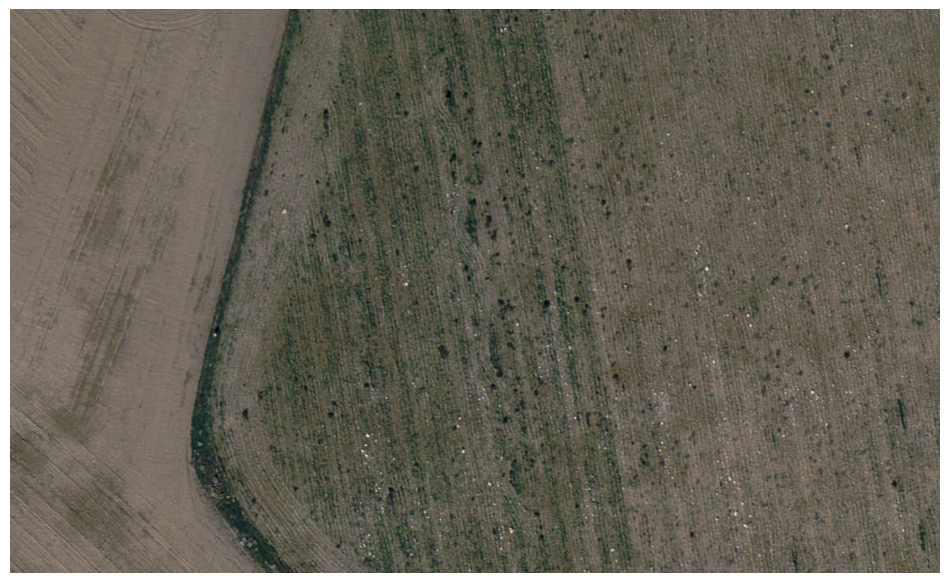

In [10]:
with rasterio.open(out_tif) as src:
    rgb = src.read([1, 2, 3]).astype(np.float32)
    print("Tamaño:", src.width, "x", src.height)
    print("CRS:", src.crs)
    print("NoData:", src.nodata)
    print("Tipo:", src.dtypes)

rgb = np.moveaxis(rgb, 0, -1)  # (h, w, 3)

valid = np.any(rgb != 0, axis=2)

# Si ya está en 0-255, solo normalizamos a 0-1
if np.nanmax(rgb) <= 255:
    rgb_vis = rgb / 255.0
else:
    rgb_vis = rgb.copy()
    for i in range(3):
        vals = rgb[..., i][valid]
        if len(vals) > 0:
            p2, p98 = np.percentile(vals, (2, 98))
            if p98 > p2:
                rgb_vis[..., i] = np.clip((rgb[..., i] - p2) / (p98 - p2), 0, 1)
            else:
                rgb_vis[..., i] = 0

rgb_vis[~valid] = 1.0  # blanco donde no haya datos

plt.figure(figsize=(12, 8))
plt.imshow(rgb_vis)
plt.axis("off")
plt.show()